# 02 데이터 정리와 EDA

KNHANES 2017-2023 데이터를 합치고, 간단한 EDA를 진행한다.

## 1. 라이브러리 불러오기

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)

In [2]:
# Run once if needed
# !pip install pyreadstat seaborn

## 2. 데이터 불러오기

원본 .sav 파일은 GitHub에 올리지 않고, local folder에 두고 사용한다.

In [3]:
from pathlib import Path

data_dir = Path('분석데이터원본')
sav_files = sorted(data_dir.glob('HN*_all.sav'))

print(len(sav_files))
sav_files

7


[WindowsPath('분석데이터원본/HN17_all.sav'),
 WindowsPath('분석데이터원본/HN18_all.sav'),
 WindowsPath('분석데이터원본/HN19_all.sav'),
 WindowsPath('분석데이터원본/HN20_all.sav'),
 WindowsPath('분석데이터원본/HN21_all.sav'),
 WindowsPath('분석데이터원본/HN22_all.sav'),
 WindowsPath('분석데이터원본/HN23_all.sav')]

## 3. 주요 변수 선택

연구에 필요한 변수만 선택한다.

In [4]:
use_cols = [
    'age', 'sex',
    'HE_BMI', 'HE_glu', 'HE_TG',
    'sm_presnt', 'dr_month', 'pa_aerobic',
    'incm', 'educ',
    'HE_sbp', 'HE_dbp'
]

In [5]:
df_list = []

for file in sav_files:
    year = 2000 + int(file.name[2:4])
    print(file.name, year)
    
    temp = pd.read_spss(file)
    temp = temp[use_cols].copy()
    temp['year'] = year
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
df.shape

HN17_all.sav 2017


HN18_all.sav 2018


HN19_all.sav 2019


HN20_all.sav 2020


HN21_all.sav 2021


HN22_all.sav 2022


HN23_all.sav 2023


(51872, 13)

In [6]:
df.head()

,age,sex,HE_BMI,HE_glu,HE_TG,sm_presnt,dr_month,pa_aerobic,incm,educ,HE_sbp,HE_dbp,year
0,76.0,1.0,21.483406,135.0,260.0,0.0,1.0,1.0,3.0,5.0,149.0,79.0,2017
1,69.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,2017
2,39.0,1.0,21.268015,85.0,93.0,1.0,1.0,0.0,1.0,7.0,115.0,78.0,2017
3,35.0,2.0,20.292201,86.0,98.0,0.0,1.0,0.0,1.0,7.0,105.0,75.0,2017
4,1.0,1.0,15.807612,NaN,NaN,NaN,NaN,NaN,2.0,88.0,NaN,NaN,2017


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51872 entries, 0 to 51871
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         51872 non-null  float64
 1   sex         51872 non-null  float64
 2   HE_BMI      49497 non-null  float64
 3   HE_glu      44029 non-null  float64
 4   HE_TG       44030 non-null  float64
 5   sm_presnt   40992 non-null  float64
 6   dr_month    44069 non-null  float64
 7   pa_aerobic  38653 non-null  float64
 8   incm        51677 non-null  float64
 9   educ        50054 non-null  float64
 10  HE_sbp      46002 non-null  float64
 11  HE_dbp      46002 non-null  float64
 12  year        51872 non-null  int64  
dtypes: float64(12), int64(1)
memory usage: 5.1 MB


## 4. COVID period 만들기

In [8]:
df['covid_period'] = 'before'
df.loc[df['year'].isin([2020, 2021]), 'covid_period'] = 'during'
df.loc[df['year'].isin([2022, 2023]), 'covid_period'] = 'after'

df[['year', 'covid_period']].head()

,year,covid_period
0,2017,before
1,2017,before
2,2017,before
3,2017,before
4,2017,before


## 5. 19-39세 대상자 선택

In [9]:
df_young = df[(df['age'] >= 19) & (df['age'] <= 39)].copy()

df_young.shape

(10974, 14)

In [10]:
df_young['age'].describe()

count    10974.000000
mean        29.846000
std          6.106588
min         19.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: age, dtype: float64

## 6. Target 변수 만들기

고혈압 여부는 SBP/DBP로 만든다. 단, 모델에서는 SBP/DBP를 feature로 사용하지 않는다.

In [11]:
df_young['hypertension'] = 0
df_young.loc[(df_young['HE_sbp'] >= 140) | (df_young['HE_dbp'] >= 90), 'hypertension'] = 1

df_young['hypertension'].value_counts()

hypertension
0    10399
1      575
Name: count, dtype: int64

## 7. 결측치 확인

In [12]:
df_young.isnull().sum()

age               0
sex               0
HE_BMI          568
HE_glu          743
HE_TG           742
sm_presnt       572
dr_month        571
pa_aerobic      975
incm             29
educ            507
HE_sbp          655
HE_dbp          655
year              0
covid_period      0
hypertension      0
dtype: int64

In [13]:
(df_young.isnull().sum() / len(df_young) * 100).round(2)

age             0.00
sex             0.00
HE_BMI          5.18
HE_glu          6.77
HE_TG           6.76
sm_presnt       5.21
dr_month        5.20
pa_aerobic      8.88
incm            0.26
educ            4.62
HE_sbp          5.97
HE_dbp          5.97
year            0.00
covid_period    0.00
hypertension    0.00
dtype: float64

## 8. 간단한 EDA

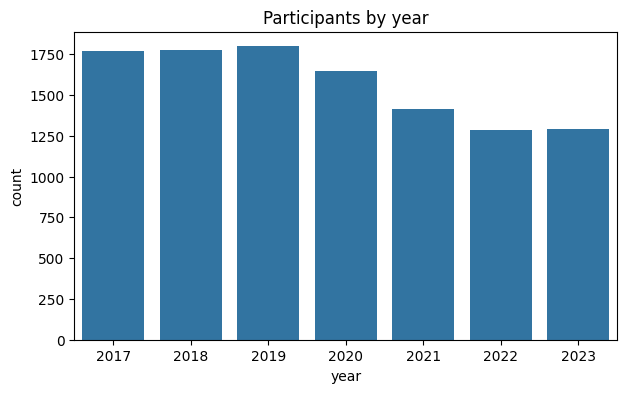

In [14]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df_young, x='year')
plt.title('Participants by year')
plt.show()

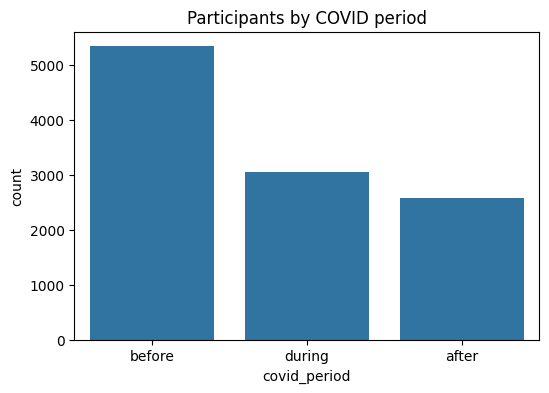

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_young, x='covid_period', order=['before', 'during', 'after'])
plt.title('Participants by COVID period')
plt.show()

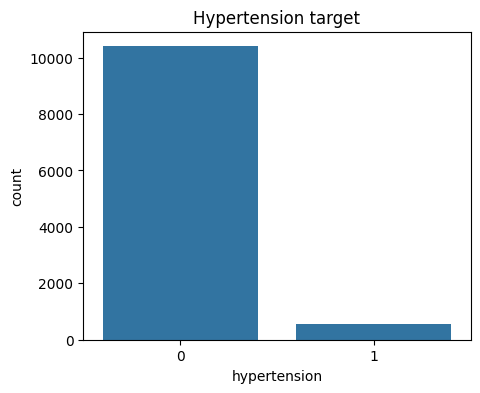

hypertension
0    0.947603
1    0.052397
Name: proportion, dtype: float64


In [16]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df_young, x='hypertension')
plt.title('Hypertension target')
plt.show()

print(df_young['hypertension'].value_counts(normalize=True))

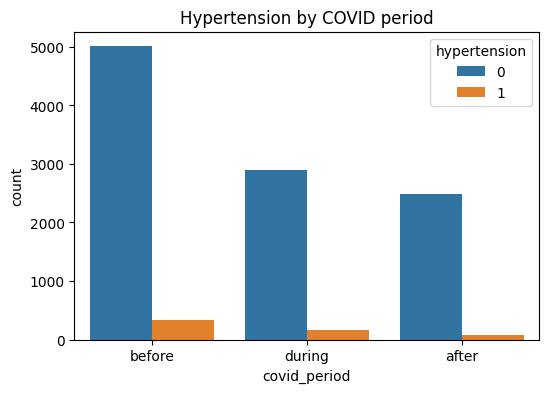

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_young, x='covid_period', hue='hypertension', order=['before', 'during', 'after'])
plt.title('Hypertension by COVID period')
plt.show()

고혈압 비율 확인

COVID period별로 고혈압 비율이 어떻게 다른지 표로 확인한다.

In [18]:
htn_period_ratio = pd.crosstab(
    df_young['covid_period'],
    df_young['hypertension'],
    normalize='index'
)

htn_period_ratio

hypertension,0,1
covid_period,,
after,0.966977,0.033023
before,0.937839,0.062161
during,0.948349,0.051651


고혈압이 있는 사람의 비율이 전체적으로 높지 않아 보인다. 그래서 모델링에서 class imbalance를 함께 고려한다.

COVID 이후 BMI 변화 확인

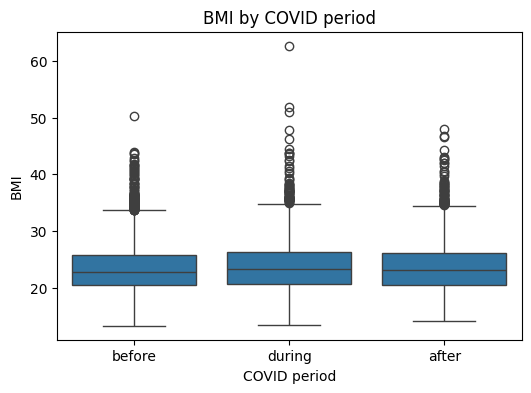

In [19]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_young, x='covid_period', y='HE_BMI', order=['before', 'during', 'after'])
plt.title('BMI by COVID period')
plt.xlabel('COVID period')
plt.ylabel('BMI')
plt.show()

COVID period별 BMI 분포를 비교하면, 기간별로 약간의 차이가 보인다. 크게 단정하기보다 모델의 하나의 입력 정보로 확인한다.

Physical activity 변화 확인

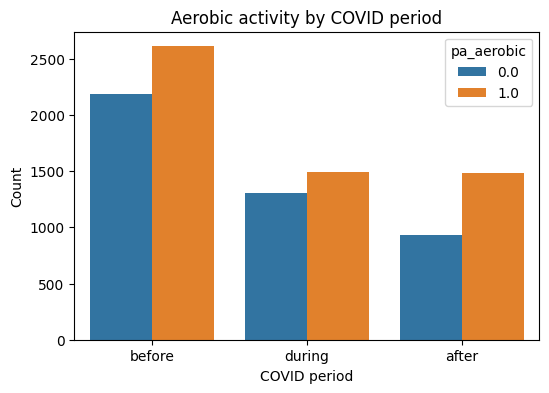

In [20]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_young, x='covid_period', hue='pa_aerobic', order=['before', 'during', 'after'])
plt.title('Aerobic activity by COVID period')
plt.xlabel('COVID period')
plt.ylabel('Count')
plt.show()

COVID 기간에 따라 유산소 운동 여부의 분포가 달라지는지 간단히 확인했다.

간단히 확인해 보면, 19-39세 대상자 중에서는 고혈압이 있는 그룹이 상대적으로 적어 보인다. 따라서 모델링에서 class imbalance를 고려할 필요가 있다.

## 9. 수치형 변수 확인

In [21]:
df_young[['age', 'HE_BMI', 'HE_glu', 'HE_TG', 'HE_sbp', 'HE_dbp']].describe()

,age,HE_BMI,HE_glu,HE_TG,HE_sbp,HE_dbp
count,10974.000000,10406.000000,10231.000000,10232.000000,10319.000000,10319.000000
mean,29.846000,23.679404,92.606979,115.029711,111.103062,72.768679
std,6.106588,4.360645,14.776962,100.516554,12.143193,9.655120
min,19.000000,13.332026,54.000000,19.000000,76.000000,34.000000
25%,25.000000,20.547633,86.000000,63.000000,102.500000,66.000000
50%,30.000000,22.981231,91.000000,89.000000,110.000000,72.000000
75%,35.000000,26.021059,96.000000,136.000000,118.000000,78.000000
max,39.000000,62.640542,370.000000,3367.000000,197.000000,130.000000


주요 수치형 변수의 상관관계

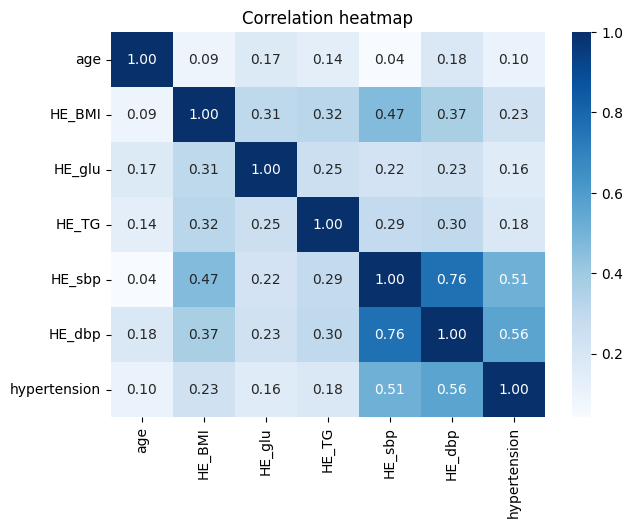

In [22]:
corr_cols = ['age', 'HE_BMI', 'HE_glu', 'HE_TG', 'HE_sbp', 'HE_dbp', 'hypertension']

plt.figure(figsize=(7, 5))
sns.heatmap(df_young[corr_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation heatmap')
plt.show()

BMI, glucose, triglycerides와 혈압 변수들의 관계를 간단히 확인했다. 다만 SBP/DBP는 target 생성에만 사용하고 모델 feature에서는 제외한다.

고혈압 여부에 따른 주요 변수 비교

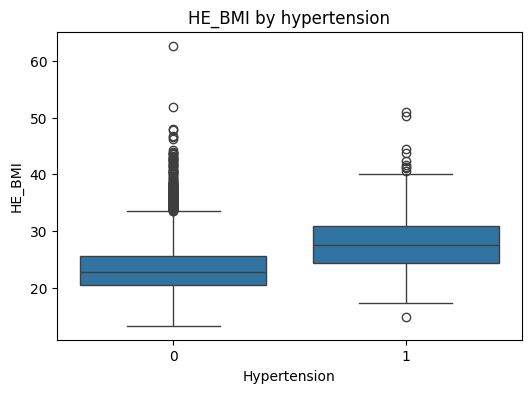

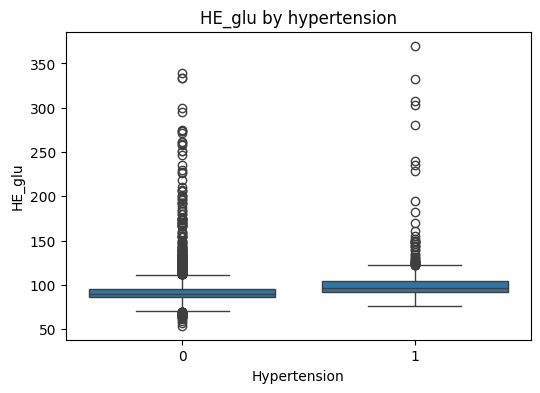

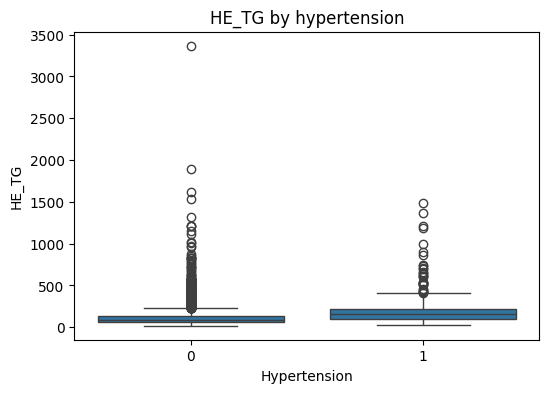

In [23]:
for col in ['HE_BMI', 'HE_glu', 'HE_TG']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_young, x='hypertension', y=col)
    plt.title(col + ' by hypertension')
    plt.xlabel('Hypertension')
    plt.ylabel(col)
    plt.show()

고혈압 그룹과 비고혈압 그룹 사이에 BMI, glucose, triglycerides 분포가 조금 다르게 나타나는지 확인했다.

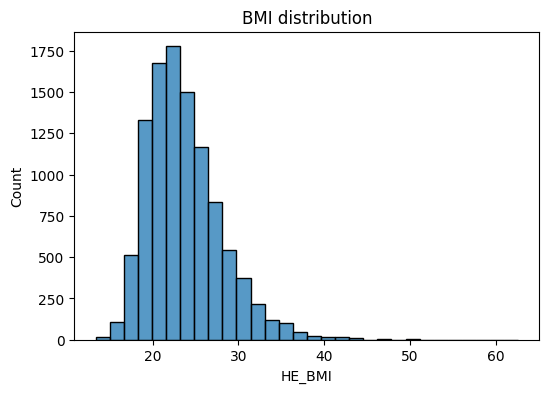

In [24]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df_young, x='HE_BMI', bins=30)
plt.title('BMI distribution')
plt.show()

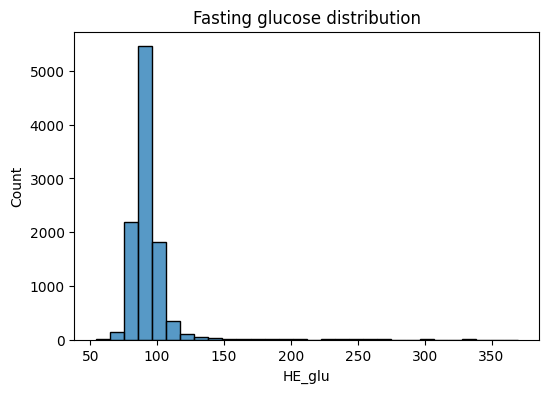

In [25]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df_young, x='HE_glu', bins=30)
plt.title('Fasting glucose distribution')
plt.show()

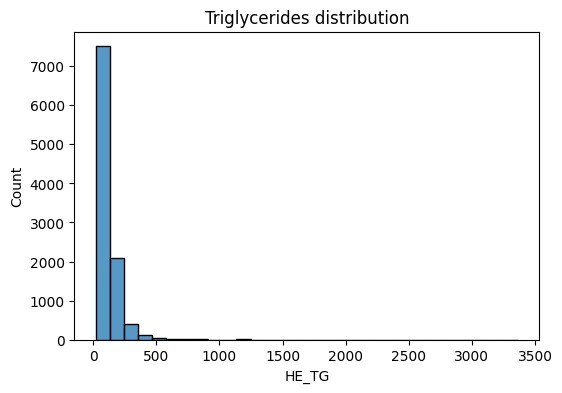

In [26]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df_young, x='HE_TG', bins=30)
plt.title('Triglycerides distribution')
plt.show()

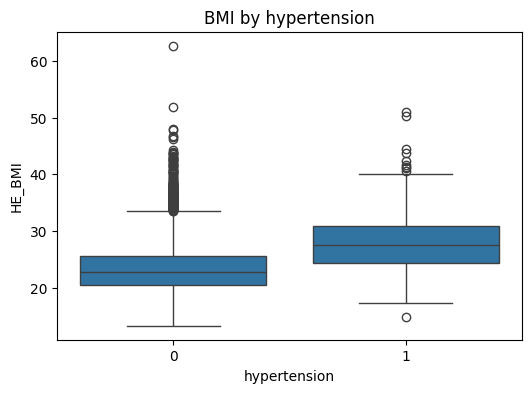

In [27]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_young, x='hypertension', y='HE_BMI')
plt.title('BMI by hypertension')
plt.show()

BMI, glucose, triglycerides는 사람마다 차이가 있고, 일부 값은 다른 값들보다 크게 나타난다. 래에서 histogram과 boxplot으로 간단히 확인한다.

## 10. 이상치 확인

이상치는 먼저 boxplot으로 확인한다. 필요하면 IQR 기준으로 대략 몇 개정도 있는지만 확인한다.

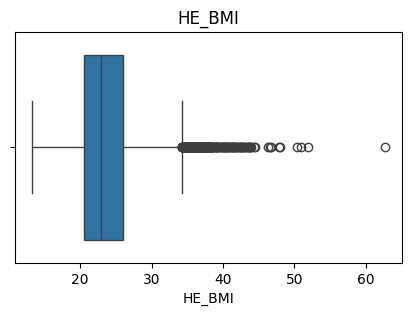

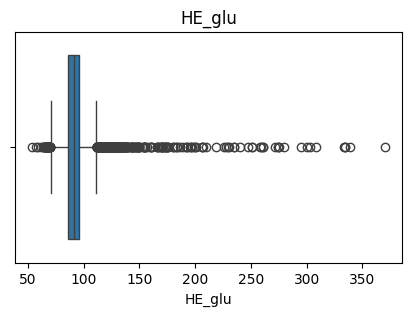

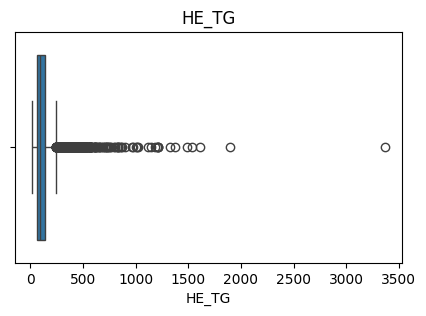

In [28]:
for col in ['HE_BMI', 'HE_glu', 'HE_TG']:
    plt.figure(figsize=(5, 3))
    sns.boxplot(data=df_young, x=col)
    plt.title(col)
    plt.show()

수업에서 다룬 median과 IQR 개념을 사용해, 값이 너무 멀리 있는 경우가 얼마나 있는지만 간단히 확인한다.

In [29]:
iqr_summary = {}

for col in ['HE_BMI', 'HE_glu', 'HE_TG']:
    q1 = df_young[col].quantile(0.25)
    q3 = df_young[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outlier_count = ((df_young[col] < lower) | (df_young[col] > upper)).sum()
    iqr_summary[col] = outlier_count

iqr_summary

{'HE_BMI': 248, 'HE_glu': 437, 'HE_TG': 613}

## 11. 정리된 데이터 저장

In [30]:
output_dir = Path('processed_data')
output_dir.mkdir(exist_ok=True)

save_path = output_dir / 'knhanes_young_hypertension_2017_2023.csv'
df_young.to_csv(save_path, index=False, encoding='utf-8-sig')

save_path

WindowsPath('processed_data/knhanes_young_hypertension_2017_2023.csv')